In [1]:
# --- CELDA 1: Importaciones y Configuración ---
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
# --- NUEVAS IMPORTACIONES ---
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
# ---------------------------
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Configuración
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_PATH = './dataset' # Tu carpeta de datos

In [2]:
# --- CELDA 2: Preprocesamiento (Data Augmentation) ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False # Importante para la matriz
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [3]:
# --- CELDA 3: Crear el Modelo Optimizado ---

# 1. Base MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

# Congelamos las primeras 120 capas (Dejamos más espacio para aprender texturas finas)
for layer in base_model.layers[:120]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

# 2. CAPAS DENSAS CON REGULARIZACIÓN (Para evitar overfitting)
# L2 castiga al modelo si memoriza demasiado
x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x) 
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x) 

predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 3. COMPILAR
# Empezamos con 1e-4, los callbacks bajarán la velocidad si es necesario
model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Modelo optimizado listo para entrenar.")

✅ Modelo optimizado listo para entrenar.


In [4]:
# --- CELDA 4: Entrenamiento Inteligente ---

# Definir Callbacks
mis_callbacks = [
    # Si la validación no mejora en 3 épocas, reduce la velocidad a la mitad
    ReduceLROnPlateau(monitor='val_accuracy', 
                      factor=0.5, 
                      patience=3, 
                      min_lr=1e-7, 
                      verbose=1),
    # Si no mejora en 10 épocas, para el entrenamiento
    EarlyStopping(monitor='val_accuracy', 
                  patience=10, 
                  restore_best_weights=True)
]

print("Iniciando entrenamiento...")
history = model.fit(
    train_generator,
    epochs=40, # Puesto en 40, pero parará antes si termina de aprender
    validation_data=validation_generator,
    callbacks=mis_callbacks
)

Iniciando entrenamiento...
Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 353ms/step - accuracy: 0.3463 - loss: 12.1580 - val_accuracy: 0.4215 - val_loss: 11.7204 - learning_rate: 1.0000e-04
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 349ms/step - accuracy: 0.6087 - loss: 11.0025 - val_accuracy: 0.4334 - val_loss: 11.2207 - learning_rate: 1.0000e-04
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 332ms/step - accuracy: 0.6937 - loss: 10.2409 - val_accuracy: 0.4195 - val_loss: 10.9996 - learning_rate: 1.0000e-04
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 330ms/step - accuracy: 0.7559 - loss: 9.5894 - val_accuracy: 0.4195 - val_loss: 10.5071 - learning_rate: 1.0000e-04
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.7859 - loss: 9.1245
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 334ms/step - accuracy: 0.7866 - loss: 8.9951 - val_accuracy: 0.4155 - val_loss: 10.2077 - learning_rate: 1.0000e-04
Epoch 6/40
64/64 ━━━━━━━━━━━━

In [5]:
# --- CELDA 5: Guardar el Modelo ---
model.save('./modelo/modelo_residuos.h5')
print("Modelo guardado como 'modelo_residuos.h5'")

Modelo guardado como 'modelo_residuos.h5'


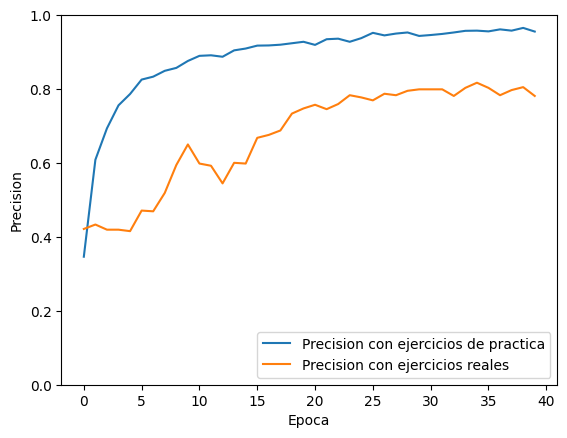

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 302ms/step


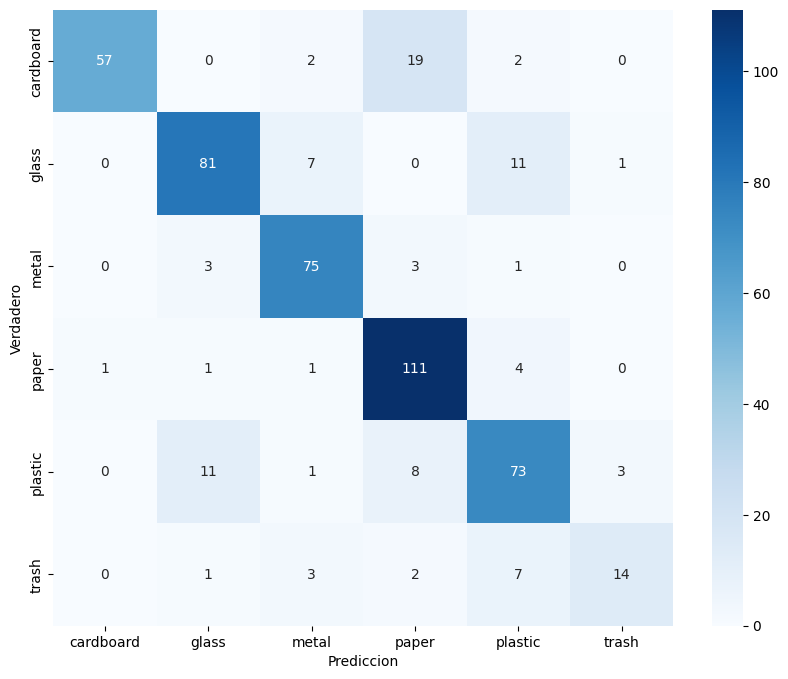

In [6]:
# --- CELDA 6: Evaluacion y Graficas ---
# Grafica de precision

plt.plot(history.history['accuracy'], label='Precision con ejercicios de practica')
plt.plot(history.history['val_accuracy'], label = 'Precision con ejercicios reales')
plt.xlabel('Epoca')
plt.ylabel('Precision')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

# Matriz de confusion
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(validation_generator.classes, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())
plt.ylabel('Verdadero')
plt.xlabel('Prediccion')
plt.show()